Cargando archivos...
  ../data/emisiones_mexico_parte1.csv: 1,044,597 filas
  ../data/emisiones_mexico_parte2.csv: 1,026,386 filas
  ../data/emisiones_mexico_parte3.csv: 1,044,597 filas
  ../data/emisiones_mexico_parte4.csv: 1,044,594 filas
  ../data/emisiones_mexico_parte5.csv: 281,629 filas

Total combinado: 4,441,803 filas

Estados disponibles: ['Aguascalientes', 'Baja California - Estatal', 'Baja California - Municipal', 'Chihuahua - Ciudad Juarez', 'Chihuahua - UACJ', 'Chihuahua -Estatal', 'Ciudad de Mexico', 'Coahuila', 'Guanajuato', 'Hidalgo', 'Jalisco', 'Mexico', 'Morelos', 'Nayarit', 'Nuevo Leon', 'Puebla', 'Queretaro', 'Sonora', 'Tlaxcala', 'Veracruz', 'Yucatan', 'Zacatecas']
Contaminantes: ['Dioxido de azufre', 'Dioxido de nitrogeno', 'Monoxido de carbono', 'Ozono', 'Particulas menores a 10 micras', 'Particulas menores a 2.5 micras']


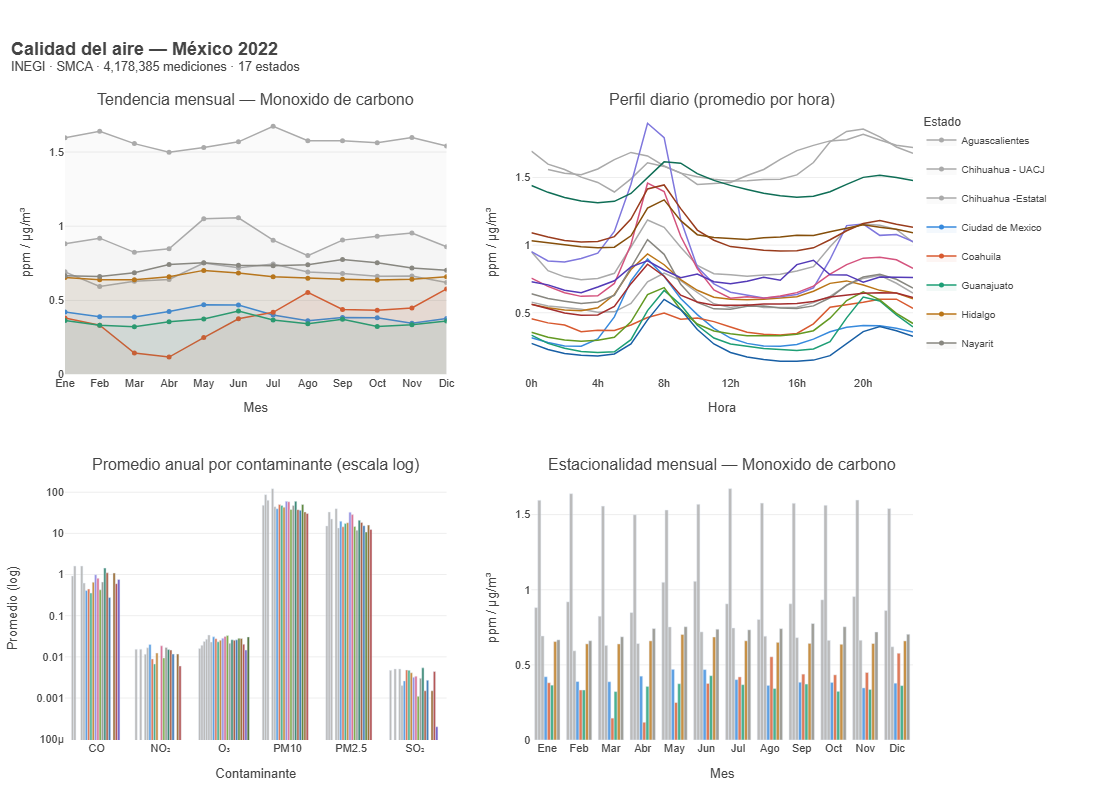

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─────────────────────────────────────────────────────────────
# 1. CARGAR DATOS
# ─────────────────────────────────────────────────────────────

archivos = [
    "../data/emisiones_mexico_parte1.csv",
    "../data/emisiones_mexico_parte2.csv",
    "../data/emisiones_mexico_parte3.csv",
    "../data/emisiones_mexico_parte4.csv",
    "../data/emisiones_mexico_parte5.csv",
]

print("Cargando archivos...")
dfs = []
for f in archivos:
    tmp = pd.read_csv(f, low_memory=False)
    print(f"  {f}: {len(tmp):,} filas")
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal combinado: {len(df):,} filas\n")

# Limpieza
df = df[df["smca"] != "Sin dato"].copy()
df = df[df["nombre_contaminante"] != "Sin dato"].copy()
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["mes"]   = df["fecha"].dt.to_period("M").astype(str)
df["hora"]  = df["hora"].fillna(0).astype(int)

print(f"Estados disponibles: {sorted(df['smca'].dropna().unique())}")
print(f"Contaminantes: {sorted(df['nombre_contaminante'].dropna().unique())}")

# ─────────────────────────────────────────────────────────────
# 2. CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────
CONTAMINANTE = "Monoxido de carbono"   # ← cambia aquí

COLORES = {
    "Ciudad de Mexico": "#378ADD",
    "Coahuila":         "#D85A30",
    "Guanajuato":       "#1D9E75",
    "Hidalgo":          "#BA7517",
    "Jalisco":          "#7F77DD",
    "Mexico":           "#D4537E",
    "Morelos":          "#639922",
    "Nayarit":          "#888780",
    "Nuevo Leon":       "#0F6E56",
    "Puebla":           "#993C1D",
    "Queretaro":        "#185FA5",
    "Sonora":           "#3B6D11",
    "Tlaxcala":         "#854F0B",
    "Veracruz":         "#A32D2D",
    "Yucatan":          "#533AB7",
    "Zacatecas":        "#27500A",
}

MESES_LABELS = {
    "2022-01": "Ene", "2022-02": "Feb", "2022-03": "Mar",
    "2022-04": "Abr", "2022-05": "May", "2022-06": "Jun",
    "2022-07": "Jul", "2022-08": "Ago", "2022-09": "Sep",
    "2022-10": "Oct", "2022-11": "Nov", "2022-12": "Dic",
}

CONT_CORTO = {
    "Dioxido de azufre":              "SO₂",
    "Dioxido de nitrogeno":           "NO₂",
    "Monoxido de carbono":            "CO",
    "Ozono":                          "O₃",
    "Particulas menores a 10 micras": "PM10",
    "Particulas menores a 2.5 micras":"PM2.5",
}

# ─────────────────────────────────────────────────────────────
# 3. DATOS AGREGADOS
# ─────────────────────────────────────────────────────────────
estados = sorted(df["smca"].dropna().unique())

# Tendencia mensual
tendencia = (
    df[df["nombre_contaminante"] == CONTAMINANTE]
    .groupby(["mes", "smca"])["valor"]
    .mean().round(4).reset_index()
)
tendencia["mes_label"] = tendencia["mes"].map(MESES_LABELS)

# Perfil diario
perfil_hora = (
    df[df["nombre_contaminante"] == CONTAMINANTE]
    .groupby(["hora", "smca"])["valor"]
    .mean().round(4).reset_index()
)

# Resumen anual por estado y contaminante
resumen = (
    df.groupby(["smca", "nombre_contaminante"])["valor"]
    .mean().round(4).reset_index()
    .rename(columns={"smca": "Estado", "nombre_contaminante": "Contaminante", "valor": "Promedio"})
)
resumen["Cont_corto"] = resumen["Contaminante"].map(CONT_CORTO).fillna(resumen["Contaminante"])

# Estacionalidad
estacional = (
    df[df["nombre_contaminante"] == CONTAMINANTE]
    .groupby(["mes", "smca"])["valor"]
    .mean().round(4).reset_index()
)
estacional["mes_label"] = estacional["mes"].map(MESES_LABELS)

# ─────────────────────────────────────────────────────────────
# 4. DASHBOARD PRINCIPAL (2×2 subplots)
# ─────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        f"Tendencia mensual — {CONTAMINANTE}",
        "Perfil diario (promedio por hora)",
        "Promedio anual por contaminante (escala log)",
        f"Estacionalidad mensual — {CONTAMINANTE}",
    ),
    vertical_spacing=0.16,
    horizontal_spacing=0.10,
)

# ── Gráfica 1: Tendencia mensual ──────────────────────────────
for i, estado in enumerate(estados):
    sub = tendencia[tendencia["smca"] == estado].sort_values("mes")
    if sub.empty:
        continue
    color = COLORES.get(estado, "#aaaaaa")
    r, g, b = int(color[1:3],16), int(color[3:5],16), int(color[5:7],16)
    fig.add_trace(
        go.Scatter(
            x=sub["mes_label"], y=sub["valor"],
            name=estado, mode="lines+markers",
            line=dict(color=color, width=1.5),
            marker=dict(size=5, color=color),
            fill="tozeroy",
            fillcolor=f"rgba({r},{g},{b},0.06)",
            legendgroup=estado, showlegend=True,
        ),
        row=1, col=1,
    )

# ── Gráfica 2: Perfil diario ──────────────────────────────────
for estado in estados:
    sub = perfil_hora[perfil_hora["smca"] == estado].sort_values("hora")
    if sub.empty:
        continue
    color = COLORES.get(estado, "#aaaaaa")
    fig.add_trace(
        go.Scatter(
            x=sub["hora"], y=sub["valor"],
            name=estado, mode="lines",
            line=dict(color=color, width=1.5),
            legendgroup=estado, showlegend=False,
        ),
        row=1, col=2,
    )

# ── Gráfica 3: Comparativa por contaminante (log) ────────────
for estado in estados:
    sub = resumen[resumen["Estado"] == estado].sort_values("Cont_corto")
    if sub.empty:
        continue
    color = COLORES.get(estado, "#aaaaaa")
    fig.add_trace(
        go.Bar(
            x=sub["Cont_corto"], y=sub["Promedio"],
            name=estado, marker_color=color, opacity=0.8,
            legendgroup=estado, showlegend=False,
        ),
        row=2, col=1,
    )

# ── Gráfica 4: Estacionalidad (barras agrupadas) ─────────────
for estado in estados:
    sub = estacional[estacional["smca"] == estado].sort_values("mes")
    if sub.empty:
        continue
    color = COLORES.get(estado, "#aaaaaa")
    fig.add_trace(
        go.Bar(
            x=sub["mes_label"], y=sub["valor"],
            name=estado, marker_color=color, opacity=0.8,
            legendgroup=estado, showlegend=False,
        ),
        row=2, col=2,
    )

# ─────────────────────────────────────────────────────────────
# 5. LAYOUT
# ─────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            "<b>Calidad del aire — México 2022</b><br>"
            "<sup>INEGI · SMCA · 4,178,385 mediciones · 17 estados</sup>"
        ),
        font=dict(size=18), x=0.01,
    ),
    height=800,
    barmode="group",
    legend=dict(
        orientation="v", x=1.01, y=1,
        font=dict(size=10),
        title=dict(text="Estado"),
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial, sans-serif", size=11, color="#444"),
    margin=dict(l=60, r=180, t=110, b=60),
)

fig.update_yaxes(type="log", row=2, col=1, title_text="Promedio (log)")
fig.update_xaxes(title_text="Mes",         row=1, col=1)
fig.update_yaxes(title_text="ppm / µg/m³", row=1, col=1)
fig.update_xaxes(
    title_text="Hora", row=1, col=2,
    tickvals=list(range(0, 24, 4)),
    ticktext=[f"{h}h" for h in range(0, 24, 4)],
)
fig.update_yaxes(title_text="ppm / µg/m³", row=1, col=2)
fig.update_xaxes(title_text="Contaminante", row=2, col=1)
fig.update_xaxes(title_text="Mes",          row=2, col=2)
fig.update_yaxes(title_text="ppm / µg/m³",  row=2, col=2)

for r in [1, 2]:
    for c in [1, 2]:
        fig.update_xaxes(showgrid=False, row=r, col=c)
        fig.update_yaxes(gridcolor="#eeeeee", row=r, col=c)

fig.show()
#fig.write_html("dashboard_emisiones_17estados.html")
#print("Dashboard guardado: dashboard_emisiones_17estados.html")


# ─────────────────────────────────────────────────────────────
# 6. GRÁFICAS INDIVIDUALES EXTRAS
# ─────────────────────────────────────────────────────────────

def graficar_tendencia(cont):
    """Tendencia mensual de un contaminante para todos los estados."""
    sub = (
        df[df["nombre_contaminante"] == cont]
        .groupby(["mes", "smca"])["valor"].mean().round(4).reset_index()
    )
    sub["mes_label"] = sub["mes"].map(MESES_LABELS)
    f = px.line(
        sub, x="mes_label", y="valor", color="smca",
        color_discrete_map=COLORES,
        title=f"Tendencia mensual — {cont} (17 estados)",
        labels={"mes_label": "Mes", "valor": "Promedio", "smca": "Estado"},
        markers=True,
    )
    f.show()


def graficar_mapa_estaciones(cont):
    """Mapa de estaciones con nivel promedio del contaminante."""
    sub = (
        df[df["nombre_contaminante"] == cont]
        .groupby(["nombre_estacion", "smca", "longitud", "latitud"])["valor"]
        .mean().round(4).reset_index()
        .dropna(subset=["longitud", "latitud"])
        .rename(columns={"nombre_estacion":"Estación","smca":"Estado","valor":"Promedio"})
    )
    f = px.scatter_mapbox(
        sub, lat="latitud", lon="longitud",
        color="Promedio", size="Promedio",
        hover_name="Estación",
        hover_data={"Estado": True, "Promedio": ":.4f"},
        color_continuous_scale="YlOrRd",
        zoom=4, center={"lat": 23.6, "lon": -102.5},
        mapbox_style="open-street-map",
        title=f"Mapa de estaciones — {cont}",
        height=600,
    )
    f.show()


def graficar_boxplot(cont):
    """Distribución de valores por estado para un contaminante."""
    sub = df[df["nombre_contaminante"] == cont]
    f = px.box(
        sub, x="smca", y="valor", color="smca",
        color_discrete_map=COLORES,
        title=f"Distribución por estado — {cont}",
        labels={"smca": "Estado", "valor": "Valor medido"},
    )
    f.update_layout(showlegend=False)
    f.show()


def graficar_heatmap_hora_mes(cont, estado):
    """Heatmap hora vs mes para un contaminante y estado."""
    sub = (
        df[(df["nombre_contaminante"] == cont) & (df["smca"] == estado)]
        .groupby(["hora", "mes"])["valor"].mean().round(4).reset_index()
    )
    sub["mes_label"] = sub["mes"].map(MESES_LABELS)
    pivot = sub.pivot(index="hora", columns="mes_label", values="valor")
    mes_order = [MESES_LABELS[m] for m in sorted(MESES_LABELS) if MESES_LABELS[m] in pivot.columns]
    pivot = pivot[mes_order]
    f = px.imshow(
        pivot,
        labels=dict(x="Mes", y="Hora", color="Promedio"),
        title=f"Heatmap hora × mes — {cont} | {estado}",
        color_continuous_scale="YlOrRd",
        aspect="auto",
    )
    f.show()
